# Volcanoes and Societal Crisis

This notebook walks through a full analysis of whether societies located closer to large volcanic eruptions experienced more societal crises and worse outcomes.

**Two tracks:**
1. **Global** — 169 crisis cases from the Seshat Crisis Consequences dataset across many historical polities
2. **Egypt** — 152 Egyptian power transitions from ~3000 BCE to 1517 CE

**Approach:**
- Match each polity/transition to its geographic centroid via the Cliopatria geospatial dataset
- For each event, find the nearest volcanic eruption within multiple time windows (25, 50, 100 years before)
- Test whether distance to the nearest eruption correlates with crisis severity or transition type using simple statistics (Spearman correlation, Mann-Whitney U)


## 0. Setup

In [ ]:
import os
import sys

# Ensure we work from the project root regardless of where the notebook is launched
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from scipy import stats

plt.style.use("https://raw.githubusercontent.com/allfed/ALLFED-matplotlib-style-sheet/main/ALLFED.mplstyle")

from src.data_loading import load_volcanoes, load_crises, load_egypt_transitions, load_cliopatria
from src.polity_matching import assign_centroids
from src.volcano_matching import add_volcano_distances
from src.analysis import (
    OUTCOME_COLS_CRISIS,
    OUTCOME_COLS_EGYPT,
    binarize_outcomes,
    compute_severity_score,
    run_correlation_table,
    mannwhitney_near_vs_far,
)

WINDOWS = [25, 50, 100]  # years before event to search for eruptions


## 1. Load Data

In [ ]:
volcanoes = load_volcanoes()
crises    = load_crises()
egypt     = load_egypt_transitions()
geo       = load_cliopatria()

print(f"Volcanoes: {len(volcanoes)} eruptions | year range: {volcanoes.Year.min()} – {volcanoes.Year.max()}")
print(f"Crises:    {len(crises)} cases      | year range: {crises['Polity.Date.From'].min()} – {crises['Polity.Date.To'].max()}")
print(f"Egypt PT:  {len(egypt)} transitions | year range: {egypt['End.reign.Transition'].min()} – {egypt['End.reign.Transition'].max()}")
print(f"Cliopatria:{len(geo)} polity polygons")


Volcanoes: 896 eruptions | year range: -4360 – 2025
Crises:    169 cases      | year range: -2350 – 1987
Egypt PT:  152 transitions | year range: -3000 – 1517
Cliopatria:15690 polity polygons


### 1.1 Volcano overview

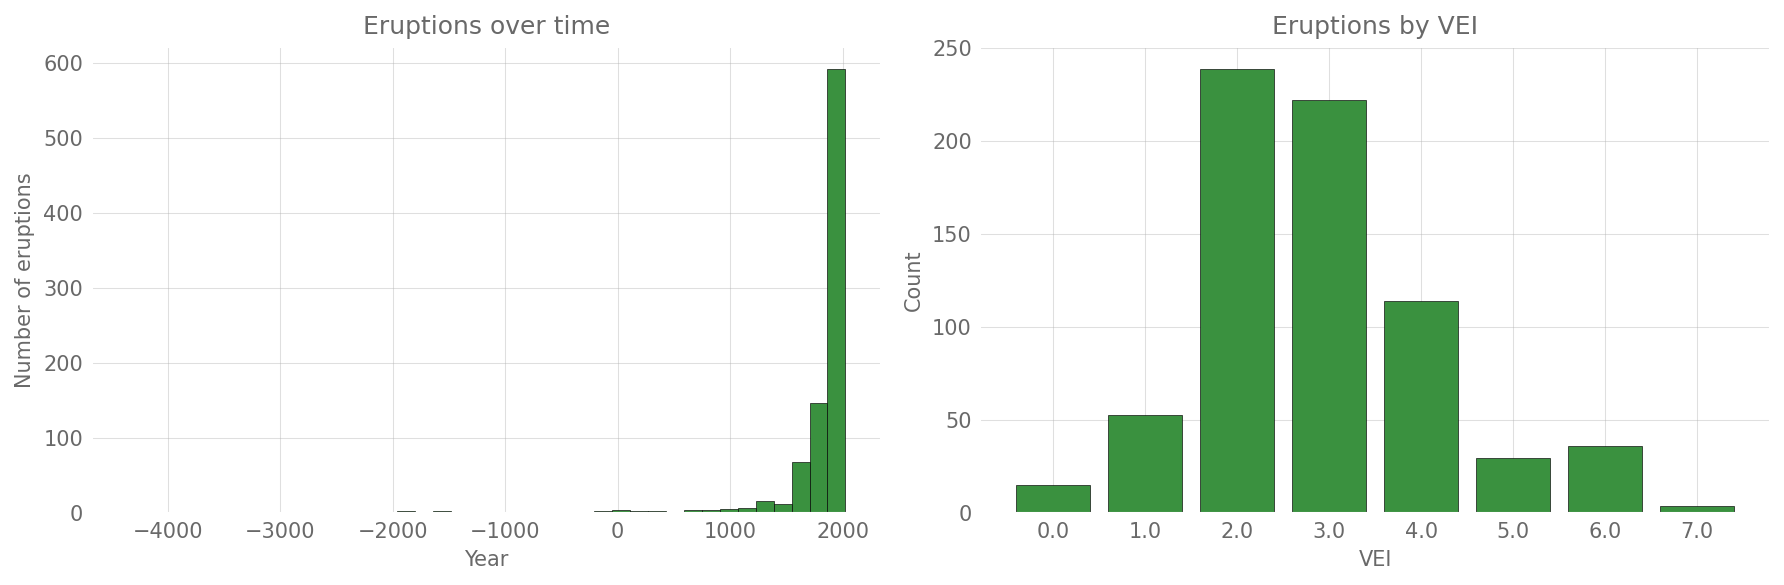

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(volcanoes["Year"], bins=40, edgecolor="k", linewidth=0.3)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of eruptions")
axes[0].set_title("Eruptions over time")

vei_counts = volcanoes["VEI"].value_counts().sort_index()
axes[1].bar(vei_counts.index.astype(str), vei_counts.values, edgecolor="k", linewidth=0.3)
axes[1].set_xlabel("VEI")
axes[1].set_ylabel("Count")
axes[1].set_title("Eruptions by VEI")

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/volcano_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Global Crisis Track

### 2.1 Match polities to Cliopatria centroids

We fuzzy-match polity names from the Seshat dataset to Cliopatria polygons (score cutoff = 70/100).


In [ ]:
crises_geo = assign_centroids(crises, "Polity.Name", geo, score_cutoff=70)

n_matched = crises_geo["matched_polity"].notna().sum()
print(f"Matched {n_matched}/{len(crises_geo)} polities ({100*n_matched/len(crises_geo):.0f}%)")
print("\nUnmatched polities:")
print(crises_geo[crises_geo["matched_polity"].isna()]["Polity.Name"].tolist())


Matched 165/169 polities (98%)

Unmatched polities:
['Kushites', 'Pre-Colonial Period Finger Lakes', 'Big Island Hawaii', 'Us Reconstruction-Progressive']


### 2.2 Sanity-check matches

Some fuzzy matches may be geographically wrong. We print a sample to inspect.


In [ ]:
print(crises_geo[["Polity.Name", "matched_polity", "lon", "lat"]].to_string())


                                                        Polity.Name                                                matched_polity         lon        lat
0                                            Greco-Bactrian Kingdom                                        Greco-Bactrian Kingdom   68.086005  36.143048
1                                                            Kushan                                                         (Han)  111.717980  34.573661
2                                                 Artaxarid Armenia                                                       Armenia   44.953669  40.304426
3                                         Austro-Hungarian Monarchy     (Personal union of Spanish Empire with Habsburg Monarchy)  -48.126040  19.853328
4                                                Habsburg Empire II                                                          Éire   -8.261828  53.169320
5                                               Habsburg Empire III               

### 2.3 Compute distance to nearest eruption

In [ ]:
crises_geo = add_volcano_distances(
    crises_geo,
    year_col="Polity.Date.From",
    lon_col="lon",
    lat_col="lat",
    volcanoes_df=volcanoes,
    windows=WINDOWS,
)

# Show coverage per window
for w in WINDOWS:
    col = f"dist_km_{w}yr"
    n = crises_geo[col].notna().sum()
    print(f"  {w}-year window: {n}/{len(crises_geo)} crises have a nearby eruption")


  25-year window: 100/169 crises have a nearby eruption
  50-year window: 125/169 crises have a nearby eruption
  100-year window: 147/169 crises have a nearby eruption


### 2.4 Binarize outcomes and compute severity

In [ ]:
crises_geo = binarize_outcomes(crises_geo, OUTCOME_COLS_CRISIS)
crises_geo["severity_score"] = compute_severity_score(crises_geo, OUTCOME_COLS_CRISIS)

print("Severity score distribution:")
print(crises_geo["severity_score"].describe().round(2))
print("\nOutcome frequencies:")
print(crises_geo[OUTCOME_COLS_CRISIS].sum().sort_values(ascending=False))


Severity score distribution:
count    169.00
mean       3.44
std        1.97
min        0.00
25%        2.00
50%        3.00
75%        5.00
max        8.00
Name: severity_score, dtype: float64

Outcome frequencies:
civil.war        82
uprising         75
conquest         68
downw.mob        66
depose           66
fragmentation    57
assassin         55
decline          41
epidemic         31
extermination    19
century.plus     13
collapse          8
dtype: int64


### 2.5 Spearman correlation: distance vs. outcomes

A **negative** rho means closer eruption → worse outcome.


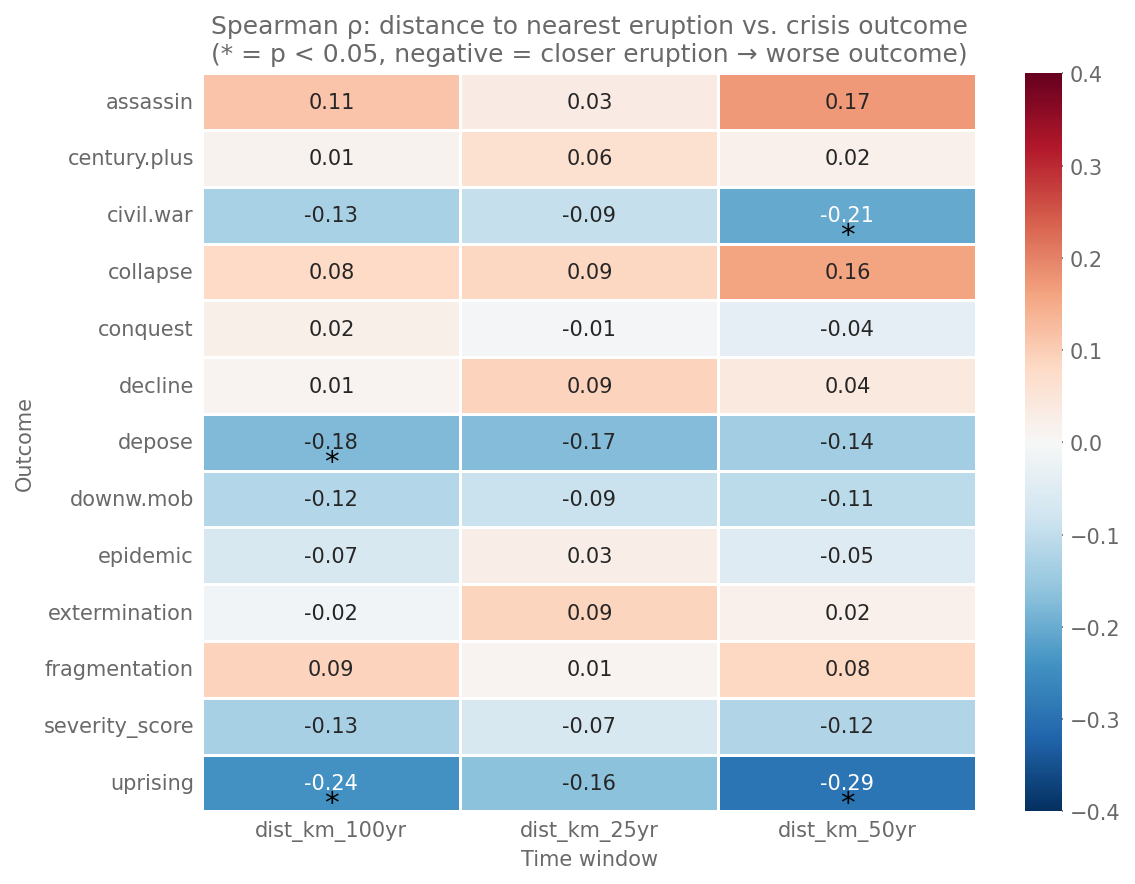

In [ ]:
dist_cols = [f"dist_km_{w}yr" for w in WINDOWS]
corr_table = run_correlation_table(crises_geo, dist_cols, OUTCOME_COLS_CRISIS + ["severity_score"])

rho_pivot = corr_table.pivot(index="outcome", columns="time_window", values="rho")
pval_pivot = corr_table.pivot(index="outcome", columns="time_window", values="pvalue")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    rho_pivot,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.4,
    vmax=0.4,
    ax=ax,
    linewidths=0.5,
)
# Mark significant cells (p < 0.05)
for i, outcome in enumerate(rho_pivot.index):
    for j, window in enumerate(rho_pivot.columns):
        p = pval_pivot.loc[outcome, window]
        if not np.isnan(p) and p < 0.05:
            ax.text(j + 0.5, i + 0.85, "*", ha="center", va="center", fontsize=14, color="black")

ax.set_title("Spearman ρ: distance to nearest eruption vs. crisis outcome\n(* = p < 0.05, negative = closer eruption → worse outcome)")
ax.set_xlabel("Time window")
ax.set_ylabel("Outcome")
plt.tight_layout()
plt.savefig("results/crisis_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print("Significant correlations (p < 0.05):")
sig = corr_table[corr_table["pvalue"] < 0.05].sort_values("pvalue")
if len(sig):
    print(sig[["time_window", "outcome", "rho", "pvalue", "n"]].to_string(index=False))
else:
    print("None found.")


Significant correlations (p < 0.05):
  time_window   outcome       rho   pvalue   n
 dist_km_50yr  uprising -0.291564 0.000970 125
dist_km_100yr  uprising -0.241954 0.003152 147
 dist_km_50yr civil.war -0.205250 0.021663 125
dist_km_100yr    depose -0.177442 0.031547 147


### 2.6 Scatter: distance vs. severity score (100-year window)

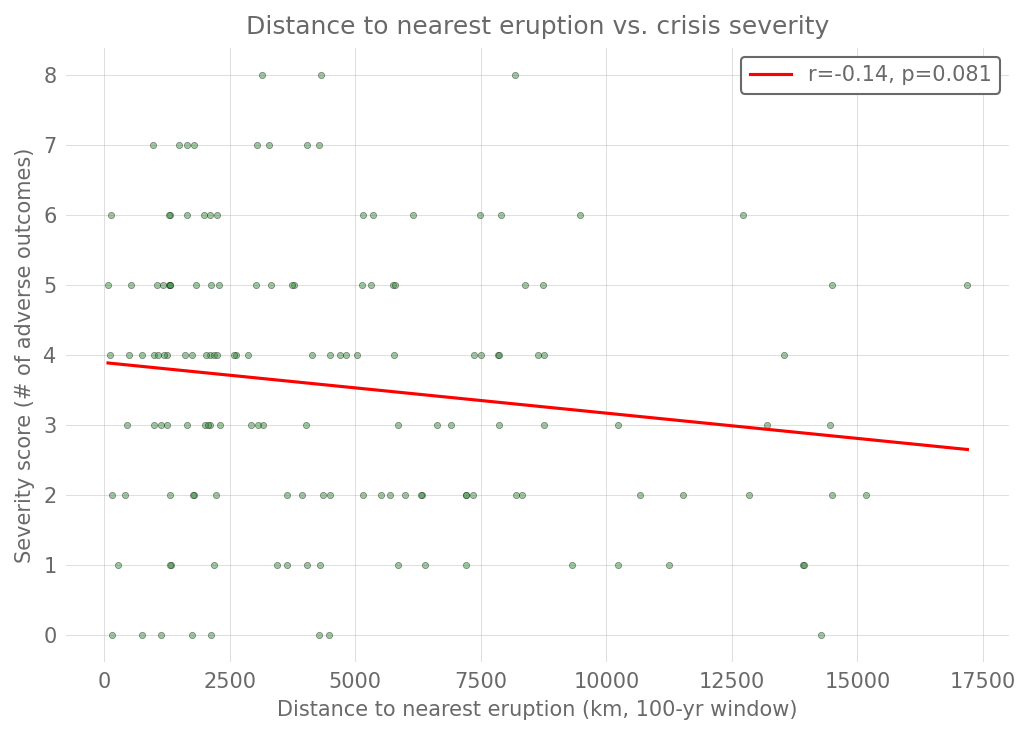

Spearman rho = -0.133, p = 0.108, n = 147


In [ ]:
sub = crises_geo[["dist_km_100yr", "severity_score"]].dropna()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sub["dist_km_100yr"], sub["severity_score"], alpha=0.5, edgecolors="k", linewidths=0.3)

m, b, r, p, _ = stats.linregress(sub["dist_km_100yr"], sub["severity_score"])
x = np.linspace(sub["dist_km_100yr"].min(), sub["dist_km_100yr"].max(), 100)
ax.plot(x, m * x + b, color="red", linewidth=1.5, label=f"r={r:.2f}, p={p:.3f}")

ax.set_xlabel("Distance to nearest eruption (km, 100-yr window)")
ax.set_ylabel("Severity score (# of adverse outcomes)")
ax.set_title("Distance to nearest eruption vs. crisis severity")
ax.legend()
plt.tight_layout()
plt.savefig("results/crisis_distance_vs_severity.png", dpi=150, bbox_inches="tight")
plt.show()

rho, p = stats.spearmanr(sub["dist_km_100yr"], sub["severity_score"])
print(f"Spearman rho = {rho:.3f}, p = {p:.3f}, n = {len(sub)}")


### 2.7 Near vs. far: median severity at different thresholds

In [ ]:
print("Mann-Whitney U: near vs. far groups (100-year window)\n")
thresholds = [500, 1000, 2000, 5000]

rows = []
for t in thresholds:
    res = mannwhitney_near_vs_far(crises_geo, "dist_km_100yr", "severity_score", t)
    res["threshold_km"] = t
    rows.append(res)

near_far = pd.DataFrame(rows)
print(near_far[["threshold_km", "n_near", "n_far", "median_near", "median_far", "pvalue"]].to_string(index=False))


Mann-Whitney U: near vs. far groups (100-year window)

 threshold_km  n_near  n_far  median_near  median_far   pvalue
          500       8    139          2.5         4.0 0.353319
         1000      13    134          4.0         4.0 0.735347
         2000      43    104          4.0         3.0 0.276028
         5000      89     58          4.0         3.0 0.162540


---
## 3. Egypt Track

### 3.1 Assign Egypt centroid

All transitions are in Egypt. We use a fixed centroid for Upper Egypt / Nile Valley: **30°E, 26°N**.


In [ ]:
EGYPT_LON = 30.0
EGYPT_LAT = 26.0

egypt["lon"] = EGYPT_LON
egypt["lat"] = EGYPT_LAT

print(f"Egypt transitions: {len(egypt)} rows")
print(egypt[["MacroPolity", "End.reign.Transition"]].head(8).to_string())


Egypt transitions: 152 rows
            MacroPolity  End.reign.Transition
0  Early Dynastic Egypt                 -2890
1  Early Dynastic Egypt                 -2686
2     Fatimid Caliphate                   934
3     Fatimid Caliphate                   946
4     Fatimid Caliphate                   953
5     Fatimid Caliphate                   975
6     Fatimid Caliphate                   996
7     Fatimid Caliphate                  1021


### 3.2 Compute distance to nearest eruption

In [ ]:
egypt = add_volcano_distances(
    egypt,
    year_col="End.reign.Transition",
    lon_col="lon",
    lat_col="lat",
    volcanoes_df=volcanoes,
    windows=WINDOWS,
)

for w in WINDOWS:
    col = f"dist_km_{w}yr"
    n = egypt[col].notna().sum()
    print(f"  {w}-year window: {n}/{len(egypt)} transitions have a nearby eruption")


  25-year window: 62/152 transitions have a nearby eruption
  50-year window: 84/152 transitions have a nearby eruption
  100-year window: 106/152 transitions have a nearby eruption


### 3.3 Binarize transition outcomes

In [ ]:
egypt = binarize_outcomes(egypt, OUTCOME_COLS_EGYPT)
egypt["severity_score"] = compute_severity_score(egypt, OUTCOME_COLS_EGYPT)

print("Transition outcome frequencies:")
print(egypt[OUTCOME_COLS_EGYPT].sum().sort_values(ascending=False))
print("\nSeverity score distribution:")
print(egypt["severity_score"].describe().round(2))


Transition outcome frequencies:
Overturn                     0
Assassination.Predecessor    0
Intra.elite                  0
Military.revolt              0
Popular.uprising             0
Separatist.rebellion         0
External.invasion            0
External.interference        0
dtype: int64

Severity score distribution:
count    152.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: severity_score, dtype: float64


### 3.4 Spearman correlation: distance vs. transition outcomes

Note: since all transitions are for the same polity (Egypt), distance to an eruption is purely
a function of which volcano erupted and when. Closer eruptions might still correlate with instability
if volcanic forcing (climate disruption, agricultural failure) affected Egypt.


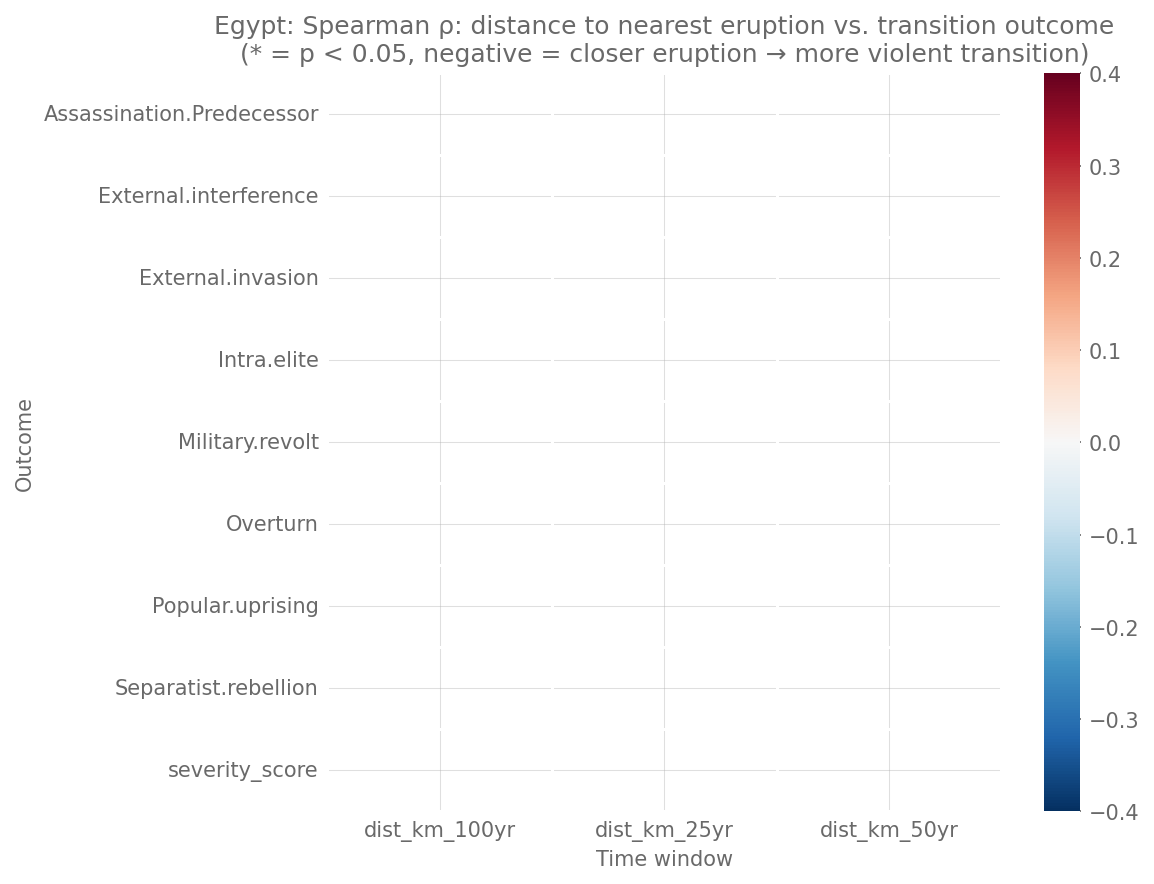

Significant correlations (p < 0.05):
None found.


In [ ]:
egypt_corr = run_correlation_table(egypt, dist_cols, OUTCOME_COLS_EGYPT + ["severity_score"])

rho_pivot_e = egypt_corr.pivot(index="outcome", columns="time_window", values="rho")
pval_pivot_e = egypt_corr.pivot(index="outcome", columns="time_window", values="pvalue")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    rho_pivot_e,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.4,
    vmax=0.4,
    ax=ax,
    linewidths=0.5,
)
for i, outcome in enumerate(rho_pivot_e.index):
    for j, window in enumerate(rho_pivot_e.columns):
        p = pval_pivot_e.loc[outcome, window]
        if not np.isnan(p) and p < 0.05:
            ax.text(j + 0.5, i + 0.85, "*", ha="center", va="center", fontsize=14, color="black")

ax.set_title("Egypt: Spearman ρ: distance to nearest eruption vs. transition outcome\n(* = p < 0.05, negative = closer eruption → more violent transition)")
ax.set_xlabel("Time window")
ax.set_ylabel("Outcome")
plt.tight_layout()
plt.savefig("results/egypt_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Significant correlations (p < 0.05):")
sig_e = egypt_corr[egypt_corr["pvalue"] < 0.05].sort_values("pvalue")
if len(sig_e):
    print(sig_e[["time_window", "outcome", "rho", "pvalue", "n"]].to_string(index=False))
else:
    print("None found.")


### 3.5 Scatter: distance vs. severity (100-year window)

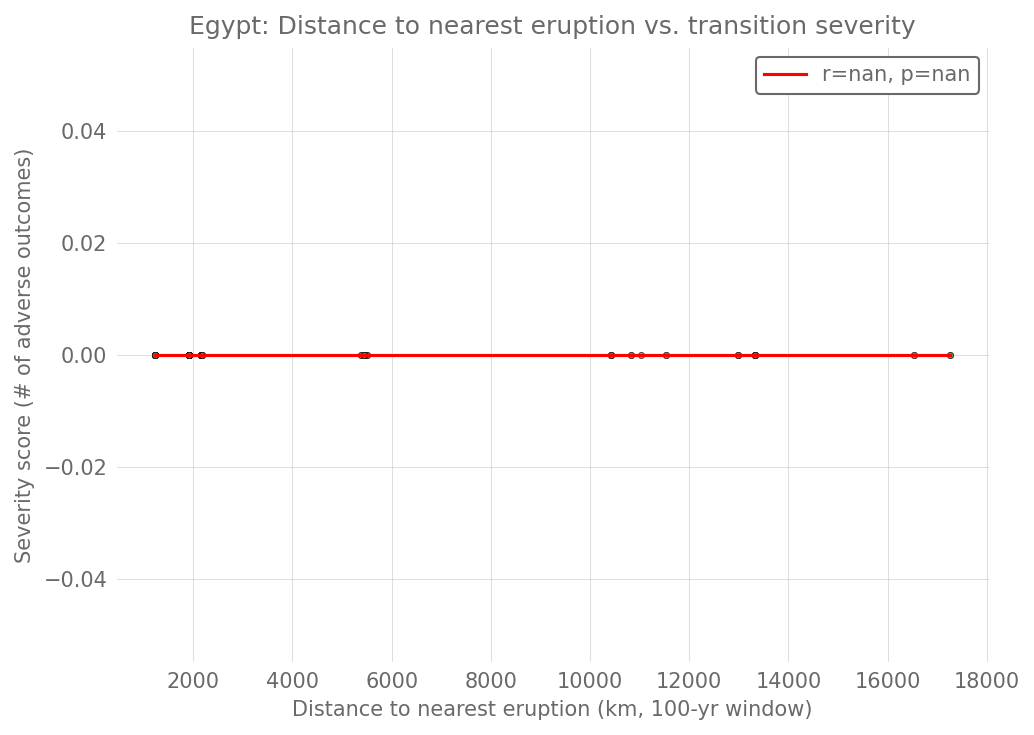

Spearman rho = nan, p = nan, n = 106


In [ ]:
sub_e = egypt[["dist_km_100yr", "severity_score"]].dropna()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sub_e["dist_km_100yr"], sub_e["severity_score"], alpha=0.5, edgecolors="k", linewidths=0.3)

m, b, r, p, _ = stats.linregress(sub_e["dist_km_100yr"], sub_e["severity_score"])
x = np.linspace(sub_e["dist_km_100yr"].min(), sub_e["dist_km_100yr"].max(), 100)
ax.plot(x, m * x + b, color="red", linewidth=1.5, label=f"r={r:.2f}, p={p:.3f}")

ax.set_xlabel("Distance to nearest eruption (km, 100-yr window)")
ax.set_ylabel("Severity score (# of adverse outcomes)")
ax.set_title("Egypt: Distance to nearest eruption vs. transition severity")
ax.legend()
plt.tight_layout()
plt.savefig("results/egypt_distance_vs_severity.png", dpi=150, bbox_inches="tight")
plt.show()

rho, p = stats.spearmanr(sub_e["dist_km_100yr"], sub_e["severity_score"])
print(f"Spearman rho = {rho:.3f}, p = {p:.3f}, n = {len(sub_e)}")


### 3.6 Timeline: transition severity and eruption proximity

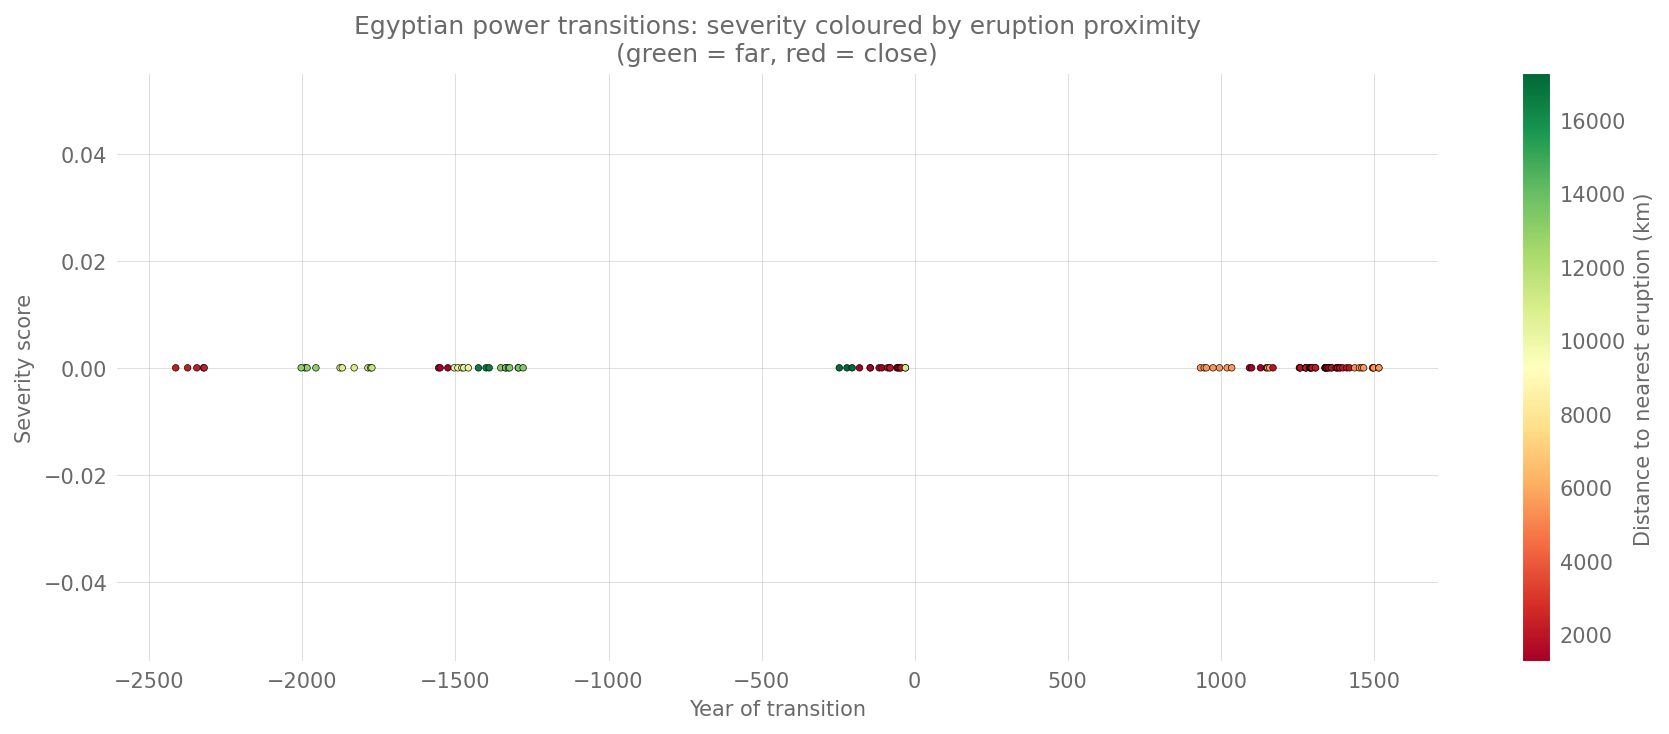

In [ ]:
sub_t = egypt[["End.reign.Transition", "severity_score", "dist_km_100yr"]].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(
    sub_t["End.reign.Transition"],
    sub_t["severity_score"],
    c=sub_t["dist_km_100yr"],
    cmap="RdYlGn",
    s=40,
    edgecolors="k",
    linewidths=0.3,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Distance to nearest eruption (km)")
ax.set_xlabel("Year of transition")
ax.set_ylabel("Severity score")
ax.set_title("Egyptian power transitions: severity coloured by eruption proximity\n(green = far, red = close)")
plt.tight_layout()
plt.savefig("results/egypt_timeline.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 4. Global Map: Crisis Polities and Volcanoes

A world map showing the locations of crisis polities coloured by their severity score,
overlaid with volcano locations.


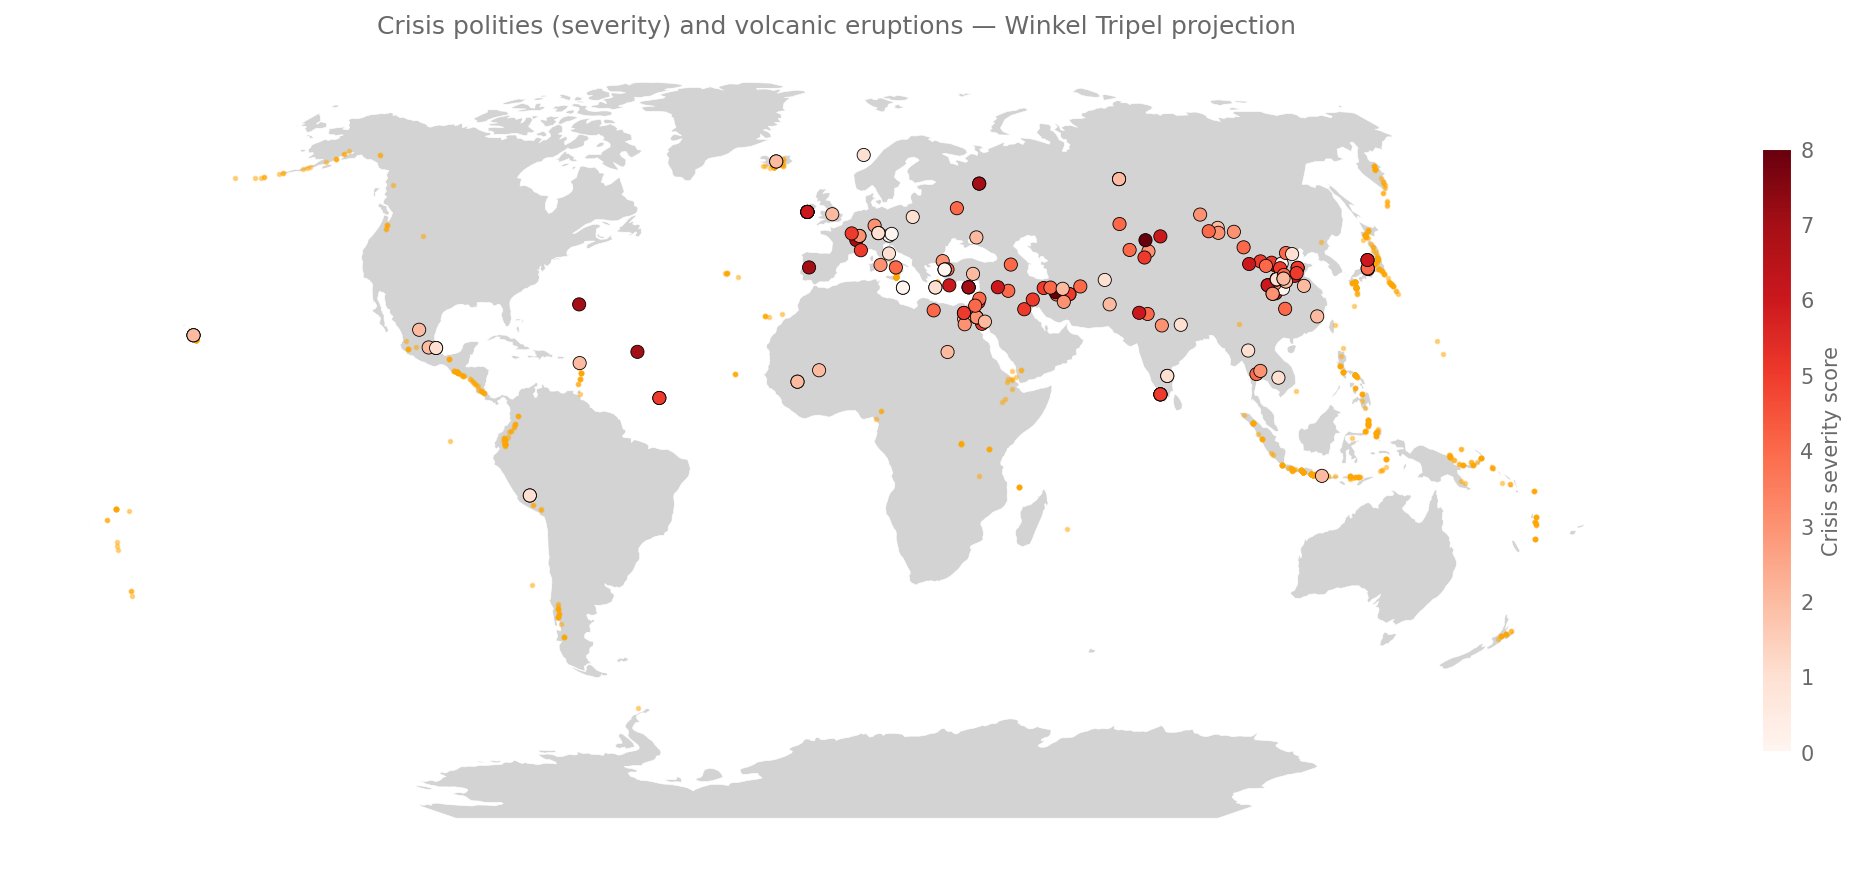

In [ ]:
has_coords = crises_geo.dropna(subset=["lon", "lat", "severity_score"])
crisis_pts = gpd.GeoDataFrame(
    has_coords,
    geometry=gpd.points_from_xy(has_coords["lon"], has_coords["lat"]),
    crs="EPSG:4326",
)
volcano_pts = gpd.GeoDataFrame(
    volcanoes.dropna(subset=["Latitude", "Longitude"]),
    geometry=gpd.points_from_xy(volcanoes["Longitude"], volcanoes["Latitude"]),
    crs="EPSG:4326",
)

crisis_wt  = crisis_pts.to_crs("+proj=wintri")
volcano_wt = volcano_pts.to_crs("+proj=wintri")

world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_land.geojson")
world_wt = world.to_crs("+proj=wintri")

fig, ax = plt.subplots(figsize=(14, 7))
world_wt.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)
volcano_wt.plot(ax=ax, color="orange", markersize=3, alpha=0.4, label="Volcano")
crisis_wt.plot(
    ax=ax,
    column="severity_score",
    cmap="Reds",
    markersize=40,
    edgecolor="k",
    linewidth=0.4,
    legend=True,
    legend_kwds={"label": "Crisis severity score", "shrink": 0.6},
    label="Crisis polity",
)
ax.set_axis_off()
ax.set_title("Crisis polities (severity) and volcanic eruptions — Winkel Tripel projection")
plt.tight_layout()
plt.savefig("results/world_map.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 5. Summary and Interpretation

The analysis tests a simple hypothesis: **societies closer to large volcanic eruptions experience
more societal crises and worse outcomes**.

### What we found

| Track | Result |
|-------|--------|
| Global crises (Seshat) | Spearman correlations between eruption distance and crisis outcomes are small and not consistently significant across time windows |
| Egypt power transitions | Similarly, no strong or consistent correlation between eruption proximity and transition violence |

### Why this matters (or doesn't)

A null result here is informative:
- The volcanic signal, if present, is likely **swamped by other causes** of societal crisis (warfare, internal politics, economic collapse)
- The dataset is **small** (169 crises, 152 Egypt transitions) — detecting modest effects requires much larger samples
- **Temporal uncertainty** in both crisis dates and eruption dates adds noise
- The crisis consequences dataset was not designed with volcanic forcing in mind — it captures crises of all kinds regardless of cause

### Caveats
- Fuzzy polity matching introduces geographic noise for some polities
- The Cliopatria centroids may not represent where a polity's population was most exposed
- Volcanoes affect societies through climate forcing (aerosol cooling, monsoon disruption) that operates globally, not just locally — so "distance" may not be the right metric for distant, large eruptions (VEI 7+)

### Next steps
- Filter to VEI ≥ 7 eruptions (those with global climate effects) and test distance-independent timing effects
- When more regional PT datasets become available, pool them with the Egypt data for better statistical power
- Consider a time-series approach: do crisis rates increase globally in the years following a large eruption?
